# Algorithm Selection Strategy: Feasibility vs. Smart Heuristic

This notebook provides the empirical evidence for the comparative analysis between the exact `FEASIBILITY` algorithm and the `SMART_HEURISTIC`.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
df = pd.read_csv('../result_feasibility_vs_heuristic.csv')

# Filter and pivot
df_filtered = df[df['algorithm'].isin(['FEASIBILITY', 'SMART_HEURISTIC'])].copy()
pivot_df = df_filtered.pivot_table(index='instance', columns='algorithm', values=['num_jumps', 'runtime'], aggfunc='first')
pivot_df.columns = [f'{val}_{col}' for val, col in pivot_df.columns]
pivot_df = pivot_df.dropna()

# Feature Merge
features = df_filtered[['instance', 'num_nodes', 'num_edges', 'mean_in_degree', 'max_in_degree', 'closed_edge_density', 'instance_type','nodes_indegree_gt_one', 'num_closed_edges']].drop_duplicates(subset=['instance'])
merged_df = pivot_df.merge(features, on='instance')
merged_df['jump_diff'] = merged_df['num_jumps_SMART_HEURISTIC'] - merged_df['num_jumps_FEASIBILITY']

merged_df.head()

,instance,num_jumps_FEASIBILITY,num_jumps_SMART_HEURISTIC,runtime_FEASIBILITY,runtime_SMART_HEURISTIC,num_nodes,num_edges,mean_in_degree,max_in_degree,closed_edge_density,instance_type,nodes_indegree_gt_one,num_closed_edges,jump_diff
0,br17.10.sop.ajn.txt,1.0,1.0,0.021302,0.004320,17,17,1.000000,2,0.227941,sop,1,31,0.0
1,br17.12.sop.ajn.txt,2.0,2.0,0.148419,0.002401,17,18,1.058824,2,0.279412,sop,2,38,0.0
2,esc07.sop.ajn.txt,2.0,2.0,0.023121,0.001385,8,9,1.125000,3,0.500000,sop,1,14,0.0
3,esc11.sop.ajn.txt,0.0,0.0,0.003753,0.001283,12,11,0.916667,1,0.242424,sop,0,16,0.0
4,esc12.sop.ajn.txt,5.0,5.0,4.044927,0.003070,13,17,1.307692,4,0.294872,sop,2,23,0.0


## 1. Quality and Performance Metrics
Understanding the global averages for both solvers.

In [14]:
exact_matches = (merged_df['jump_diff'] == 0).sum()
total = len(merged_df)
print(f"Total Instances: {total}")
print(f"Exact Matches found by Heuristic: {exact_matches} ({(exact_matches/total)*100:.2f}%)")
print(f"Average Jump Deviation: {merged_df['jump_diff'].mean():.2f}")
print(f"Max Jump Deviation: {merged_df['jump_diff'].max():.2f}")
print(f"Mean Exact Solver Runtime: {merged_df['runtime_FEASIBILITY'].mean():.2f}s")
print(f"Mean Heuristic Runtime: {merged_df['runtime_SMART_HEURISTIC'].mean():.2f}s")

Total Instances: 187
Exact Matches found by Heuristic: 126 (67.38%)
Average Jump Deviation: 0.47
Max Jump Deviation: 4.00
Mean Exact Solver Runtime: 1931.47s
Mean Heuristic Runtime: 0.02s


## 2. Correlation Analysis: Influencing Metrics
Determining which graph properties impact the Exact Solver's runtime and the Heuristic's accuracy gap.

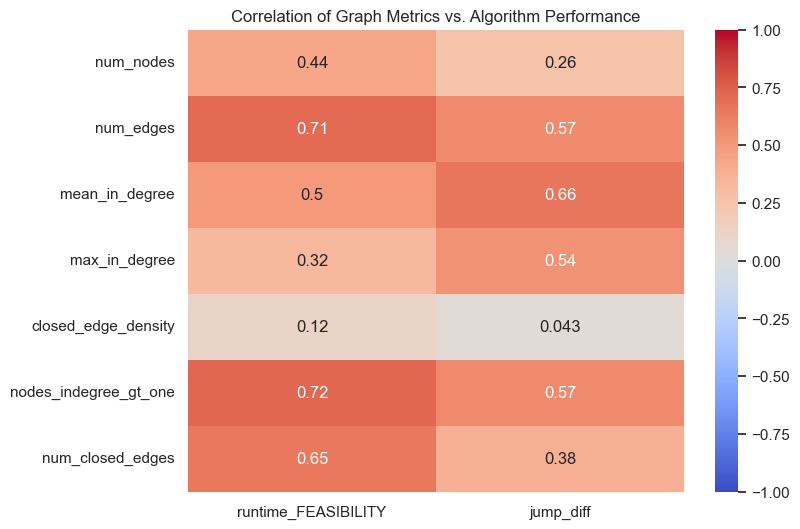

In [15]:
corr_cols = ['runtime_FEASIBILITY', 'jump_diff', 'num_nodes', 'num_edges', 'mean_in_degree', 'max_in_degree', 'closed_edge_density', 'nodes_indegree_gt_one', 'num_closed_edges']

corr_matrix = merged_df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix[['runtime_FEASIBILITY', 'jump_diff']].drop(['runtime_FEASIBILITY', 'jump_diff']), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation of Graph Metrics vs. Algorithm Performance')
plt.show()

## 3. Threshold Analysis
Let's visualize the tradeoff using `num_edges` as the primary threshold parameter since it has the highest correlation with exact solver runtime.

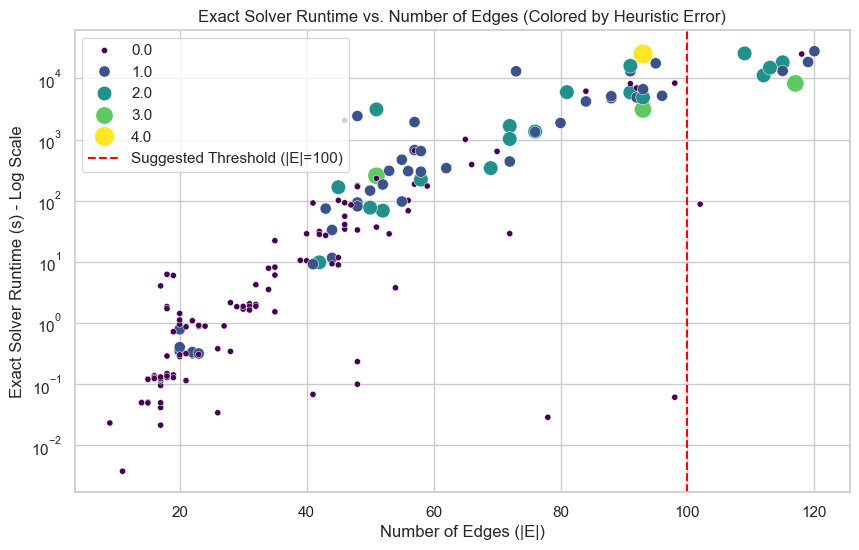

In [4]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=merged_df, x='num_edges', y='runtime_FEASIBILITY', hue='jump_diff', palette='viridis', size='jump_diff', sizes=(20, 200))
plt.axvline(x=100, color='red', linestyle='--', label='Suggested Threshold (|E|=100)')
plt.yscale('log')
plt.title('Exact Solver Runtime vs. Number of Edges (Colored by Heuristic Error)')
plt.xlabel('Number of Edges (|E|)')
plt.ylabel('Exact Solver Runtime (s) - Log Scale')
plt.legend()
plt.show()

### Statistical breakdown based on Edge Threshold (|E| = 100)

In [5]:
low_edges = merged_df[merged_df['num_edges'] <= 100]
high_edges = merged_df[merged_df['num_edges'] > 100]

summary = pd.DataFrame({
    'Metric': ['Count', 'Mean Runtime (FEAS)', 'Mean Jump Diff', 'Exact Match %'],
    '|E| <= 100': [len(low_edges), low_edges['runtime_FEASIBILITY'].mean(), low_edges['jump_diff'].mean(), (low_edges['jump_diff']==0).mean()*100],
    '|E| > 100': [len(high_edges), high_edges['runtime_FEASIBILITY'].mean(), high_edges['jump_diff'].mean(), (high_edges['jump_diff']==0).mean()*100]
})
display(summary.round(2))

,Metric,|E| <= 100,|E| > 100
0,Count,177.00,10.0
1,Mean Runtime (FEAS),1117.21,16343.9
2,Mean Jump Diff,0.42,1.4
3,Exact Match %,70.06,20.0


## 4. Intractability of the Exact Solver (Heuristic-Only Instances)
The previous analysis focused on the 187 instances where both solvers reached a solution. However, a crucial advantage of the SMART_HEURISTIC is its ability to scale where the exact solver fails. Out of 449 evaluated instances, 262 were solved exclusively by the heuristic.

In [6]:
# Identify instances solved only by the heuristic
heur_only_df = df[~df['instance'].isin(df[df['algorithm'] == 'FEASIBILITY']['instance'])]

print(f"Total evaluated instances: {len(df['instance'].unique())}")
print(f"Solved by both solvers: {len(pivot_df)}")
print(f"Solved exclusively by Heuristic: {len(heur_only_df)}")

print("\n--- Breakdown of Heuristic-Only Instances by Group ---")
display(heur_only_df['group_id'].value_counts().to_frame(name='Count'))

print("\n--- Breakdown of Heuristic-Only Instances by Type ---")
display(heur_only_df['instance_type'].value_counts().to_frame(name='Count'))


Total evaluated instances: 449
Solved by both solvers: 187
Solved exclusively by Heuristic: 262

--- Breakdown of Heuristic-Only Instances by Group ---


,Count
n70,60
n60,60
n40,50
n50,41
sop,23
n30,20
n20,8



--- Breakdown of Heuristic-Only Instances by Type ---


,Count
generated,239
sop,23
